In [27]:
%reset -f

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import RectBivariateSpline
import os

torch.set_default_dtype(torch.float64)

# Device setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## 1. SOLVER: Two-Layer Heat Equation

In [29]:
def set_BCs(T):
    T[0]  = T[2]
    T[-1] = T[-2] ** 2 / max(T[-3].item(), 1e-40)

def avg_2_center(T, m):
    Tc = T.clone()
    Tc[m] = (8*T[m]-T[m-1]-T[m+1])/6
    return Tc

def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True):
    """
    Solve the two-layer heat equation from t=0 to t=tf.
    Returns solution on device.
    """
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device, dtype=torch.float64) * dz
    m  = torch.searchsorted(z, z_dis - 0.5 * dz, right=True).item()
    if verbose:
        print(f'device: {device},  nz={nz},  tf={tf},  M={M}')
        print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')
    k_iL = 8 * k1 * k2 / (k1 + 7 * k2)
    k_iR = 8 * k1 * k2 / (7 * k1 + k2)
    kh   = torch.where(
        z[:-1] < z_dis - 0.5 * dz,
        torch.tensor(k1, device=device, dtype=torch.float64),
        torch.tensor(k2, device=device, dtype=torch.float64),
    )
    kh[m - 1] = k_iL
    kh[m]     = k_iR
    
    dt_stab = 0.5 * (dz ** 2) / max(k1, k2)
    dt_want = tf/M
    nt_skip = int(np.ceil(dt_want/dt_stab))
    dt = dt_want/nt_skip
    dM = 5
    nt_num = (M+dM)*nt_skip
    delta   = nt_skip * dt
    t_out = torch.arange(0, M+dM+1, device=device, dtype=torch.float64)*delta
    U_out = torch.zeros(nz+1, M+dM+1, device=device, dtype=torch.float64)
    if verbose:
        print(f'dt_stab={dt_stab:.4e}  dt={dt:.4e}  nt_num={nt_num}  tf_num = {nt_num*dt}')
        print(f'nt_skip={nt_skip}  delta={delta:.6f}')
    
    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2]/4)
    T = torch.zeros(nz + 3, device=device, dtype=torch.float64)
    i_save = 0
    for step in range(1, nt_num+1):
        set_BCs(T)
        Jh      = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        if step % nt_skip == 0:
            i_save += 1
            U_out[:,i_save] = avg_2_center(T, m)[1:-1]
    set_BCs(T)
    T[m] = T[m] + (2 * T[m] - T[m - 1] - T[m + 1]) / 6
    print(f't_out.shape = {t_out.shape},  U_out.shape = {U_out.shape}\n')
    return {'z': z[1:-1], 't_out': t_out, 'U_out': U_out, 'nt_skip': nt_skip, 'delta': delta}

print('✓ Solver defined')

✓ Solver defined


## 2. INTERPOLATION FUNCTIONS (Piecewise)

In [30]:
def pt_2d_interpolation(z, t, U, **kwargs):
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    original_device = U.device
    rbs = RectBivariateSpline(
        z.cpu().numpy(), t.cpu().numpy(), U.cpu().numpy(), **defaults,
    )
    def interp(z_q, t_q, **ev_kwargs):
        z_q = torch.as_tensor(z_q, dtype=U.dtype)
        t_q = torch.as_tensor(t_q, dtype=U.dtype)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        vals = rbs.ev(z_q.cpu().numpy(), t_q.cpu().numpy(), **ev_kwargs)
        return torch.from_numpy(vals).to(device=original_device, dtype=U.dtype)
    interp._rbs = rbs
    return interp

def pt_2d_interp_piecewise(z, t, U, z_dis, **kwargs):
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    min_pts = defaults['kx'] + 1
    m = torch.searchsorted(z, torch.tensor(z_dis, device=z.device)).item()
    n_left  = m + 1
    n_right = len(z) - m
    if n_left < min_pts or n_right < min_pts:
        print(f'[interp_pw] warning: {n_left} left / {n_right} right points')
        return pt_2d_interpolation(z, t, U, **defaults)
    interp_L = pt_2d_interpolation(z[:m+1], t, U[:m+1, :], **defaults)
    interp_R = pt_2d_interpolation(z[m:],   t, U[m:,   :], **defaults)
    def interp(z_q, t_q, **ev_kwargs):
        device = z.device
        z_q = torch.as_tensor(z_q, dtype=z.dtype, device=device)
        t_q = torch.as_tensor(t_q, dtype=t.dtype, device=device)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        out  = torch.zeros_like(z_q, device=device)
        mask = z_q <= z_dis
        if mask.any():
            result_L = interp_L(z_q[mask],  t_q[mask],  **ev_kwargs)
            out[mask]  = result_L.to(device=device, dtype=out.dtype)
        if (~mask).any():
            result_R = interp_R(z_q[~mask], t_q[~mask], **ev_kwargs)
            out[~mask] = result_R.to(device=device, dtype=out.dtype)
        return out
    return interp

print('✓ Interpolation functions defined')

✓ Interpolation functions defined


## 3. PROBLEM SETUP & SOLVE

In [31]:
# Problem parameters
k1, k2  = 1.0, 2.0
z_dis   = 1.0
Pda     = 1.0
Lz      = 16.0
tf      = 20.0
nz      = 640
M       = 320

print(f'Problem: k1={k1}, k2={k2}, z_dis={z_dis}, Lz={Lz}, tf={tf}')

Problem: k1=1.0, k2=2.0, z_dis=1.0, Lz=16.0, tf=20.0


In [32]:
%%time
# Solve the PDE
R = solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True)

device: cuda,  nz=640,  tf=20.0,  M=320
Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  dt=1.5625e-04  nt_num=130000  tf_num = 20.3125
nt_skip=400  delta=0.062500
t_out.shape = torch.Size([326]),  U_out.shape = torch.Size([641, 326])

CPU times: user 10.7 s, sys: 14.1 ms, total: 10.7 s
Wall time: 10.7 s


In [33]:
# Create best interpolator (piecewise)
interp_pw = pt_2d_interp_piecewise(
    R['z'], R['t_out'], R['U_out'], z_dis, kx=3, ky=3, s=0
)
print('✓ Piecewise interpolator created')

✓ Piecewise interpolator created


## 4. TRAINING DATA GENERATION: ALL ON CUDA AS TENSORS

In [34]:
print("="*80)
print("TRAINING DATA GENERATION")
print(f"ALL DATA ON CUDA: {device}")
print("="*80)

# Hyperparameters
n_s = 300
n_tau = 150

# Create grids DIRECTLY on CUDA as tensors (NO numpy)
s_t = torch.linspace(0, 1, n_s, device=device, dtype=torch.float64)
tau_t = torch.linspace(0.01, 1, n_tau, device=device, dtype=torch.float64)

print(f"\n[1] Uniform (s, τ) grid:")
print(f"    - s:   {n_s} points")
print(f"    - τ:   {n_tau} points")
print(f"    - Total: {n_s * n_tau:,} samples")
print(f"    - All tensors on: {s_t.device}")

# Get bounds as scalars
z_min = R['z'].min().item()
z_max = R['z'].max().item()
t_min = R['t_out'].min().item()
t_max = R['t_out'].max().item()

print(f"\n[2] Coordinate transformations:")
print(f"    - z ∈ [{z_min:.4f}, {z_max:.4f}]")
print(f"    - t ∈ [{t_min:.4f}, {t_max:.4f}]")

def transform_s_tau_to_z_t(s, tau):
    """Transform (s, τ) → (z, t). Returns tensors on device."""
    z = z_min + s * (z_max - z_min)
    t = t_min + tau * (t_max - t_min)
    return z, t

# Create meshgrid on CUDA
S, TAU = torch.meshgrid(s_t, tau_t, indexing='ij')
Z_train, T_train = transform_s_tau_to_z_t(S, TAU)

print(f"\n[3] Evaluate solution on training grid...")
U_train = interp_pw(Z_train, T_train)  # Returns tensor on device
print(f"    ✓ U_train shape: {U_train.shape}")
print(f"    ✓ U_train device: {U_train.device}")

# Flatten data (keep as tensors on device)
N_samples = n_s * n_tau
s_flat = S.reshape(-1)
tau_flat = TAU.reshape(-1)
u_flat = U_train.reshape(-1)

print(f"\n[4] Prepare data for training:")
print(f"    - Total samples: {N_samples:,}")
print(f"    - U: min={u_flat.min():.6e}, max={u_flat.max():.6e}")
print(f"    - U: mean={u_flat.mean():.6e}, std={u_flat.std():.6e}")

TRAINING DATA GENERATION
ALL DATA ON CUDA: cuda

[1] Uniform (s, τ) grid:
    - s:   300 points
    - τ:   150 points
    - Total: 45,000 samples
    - All tensors on: cuda:0

[2] Coordinate transformations:
    - z ∈ [0.0000, 16.0000]
    - t ∈ [0.0000, 20.3125]

[3] Evaluate solution on training grid...
    ✓ U_train shape: torch.Size([300, 150])
    ✓ U_train device: cuda:0

[4] Prepare data for training:
    - Total samples: 45,000
    - U: min=2.819498e-08, max=3.291429e+00
    - U: mean=6.362709e-01, std=7.577137e-01


## 5. SAVE as 4 KEYS (ALL ON CUDA)

In [38]:
os.makedirs('./data', exist_ok=True)

print("\n[5] SAVING TRAINING DATA (4 keys - ALL ON CUDA)")

# Prepare the 4 required keys (ALL as CUDA tensors)
# Key 1: stau - 2D tensor with s and tau columns (on device)
stau = torch.stack([s_flat, tau_flat], dim=1).to(device=device, dtype=torch.float64)

# Key 2: W - the solution (targets) - reshape to (N, 1) (on device)
W = u_flat.reshape(-1, 1).to(device=device, dtype=torch.float64)

# Key 3: kratio - k1/k2 ratio (broadcast to all samples) (on device)
kratio = torch.full((N_samples,), k1 / k2, dtype=torch.float64, device=device)

# Key 4: zdis - interface location (broadcast to all samples) (on device)
z_disv = torch.full((N_samples,), z_dis, dtype=torch.float64, device=device)

# Create dictionary with 4 keys (all on CUDA)
training_dict = {
    'stau': stau,
    'W': W,
    'kratio': kratio,
    'zdis': z_disv
}

# Save to .pt file
dat_file = f'./data/2layer_k1{k1}_k2{k2}_ns{n_s}.pt'
torch.save(training_dict, dat_file)

print(f"    ✓ Saved: {dat_file}")
print(f"\n    Dictionary keys (all on {device}):")
for key, val in training_dict.items():
    print(f"      - {key:12s}: shape={str(val.shape):20s} dtype={str(val.dtype):20s} device={val.device}")


[5] SAVING TRAINING DATA (4 keys - ALL ON CUDA)
    ✓ Saved: ./data/2layer_k11.0_k22.0_ns300.pt

    Dictionary keys (all on cuda):
      - stau        : shape=torch.Size([45000, 2]) dtype=torch.float64        device=cuda:0
      - W           : shape=torch.Size([45000, 1]) dtype=torch.float64        device=cuda:0
      - kratio      : shape=torch.Size([45000])  dtype=torch.float64        device=cuda:0
      - zdis        : shape=torch.Size([45000])  dtype=torch.float64        device=cuda:0


## 6. VERIFICATION (Load and prepare for training)

In [39]:
print("\n[6] VERIFICATION (load like 2layertrain.ipynb)")

# Load data
trn_dat = torch.load(dat_file, weights_only=True)

# Move to device if needed
stau_test = trn_dat['stau'].to(device, dtype=torch.float64)
W_test = trn_dat['W'].to(device, dtype=torch.float64)
kratio_test = trn_dat['kratio'].to(device, dtype=torch.float64)
z_disv_test = trn_dat['zdis'].to(device, dtype=torch.float64)

# Stack like 2layertrain.ipynb does
train = torch.stack([stau_test[:,0], stau_test[:,1], kratio_test, z_disv_test], dim=-1)
xtrain = train.to(torch.float64)
ytrain = W_test.to(torch.float64)

print(f"\n    xtrain shape: {xtrain.shape}  (should be ({N_samples}, 4))")
print(f"    xtrain device: {xtrain.device}")
print(f"    xtrain dtype: {xtrain.dtype}")
print(f"\n    ytrain shape: {ytrain.shape}  (should be ({N_samples}, 1))")
print(f"    ytrain device: {ytrain.device}")
print(f"    ytrain dtype: {ytrain.dtype}")

print(f"\n    ✓ Format matches 2layertrain.ipynb expectations")
print(f"    ✓ All data is on {device}")
print(f"    ✓ All tensors are float64")
print(f"    ✓ Ready for training!")

print(f"\n{'='*80}")
print("✓ TRAINING DATA READY FOR 2layertrain.ipynb")
print(f"{'='*80}")
print(f"\nUse in 2layertrain.ipynb with:")
print(f"  dat_file = '{dat_file}'")


[6] VERIFICATION (load like 2layertrain.ipynb)

    xtrain shape: torch.Size([45000, 4])  (should be (45000, 4))
    xtrain device: cuda:0
    xtrain dtype: torch.float64

    ytrain shape: torch.Size([45000, 1])  (should be (45000, 1))
    ytrain device: cuda:0
    ytrain dtype: torch.float64

    ✓ Format matches 2layertrain.ipynb expectations
    ✓ All data is on cuda
    ✓ All tensors are float64
    ✓ Ready for training!

✓ TRAINING DATA READY FOR 2layertrain.ipynb

Use in 2layertrain.ipynb with:
  dat_file = './data/2layer_k11.0_k22.0_ns300.pt'


## 7. VISUALIZATION

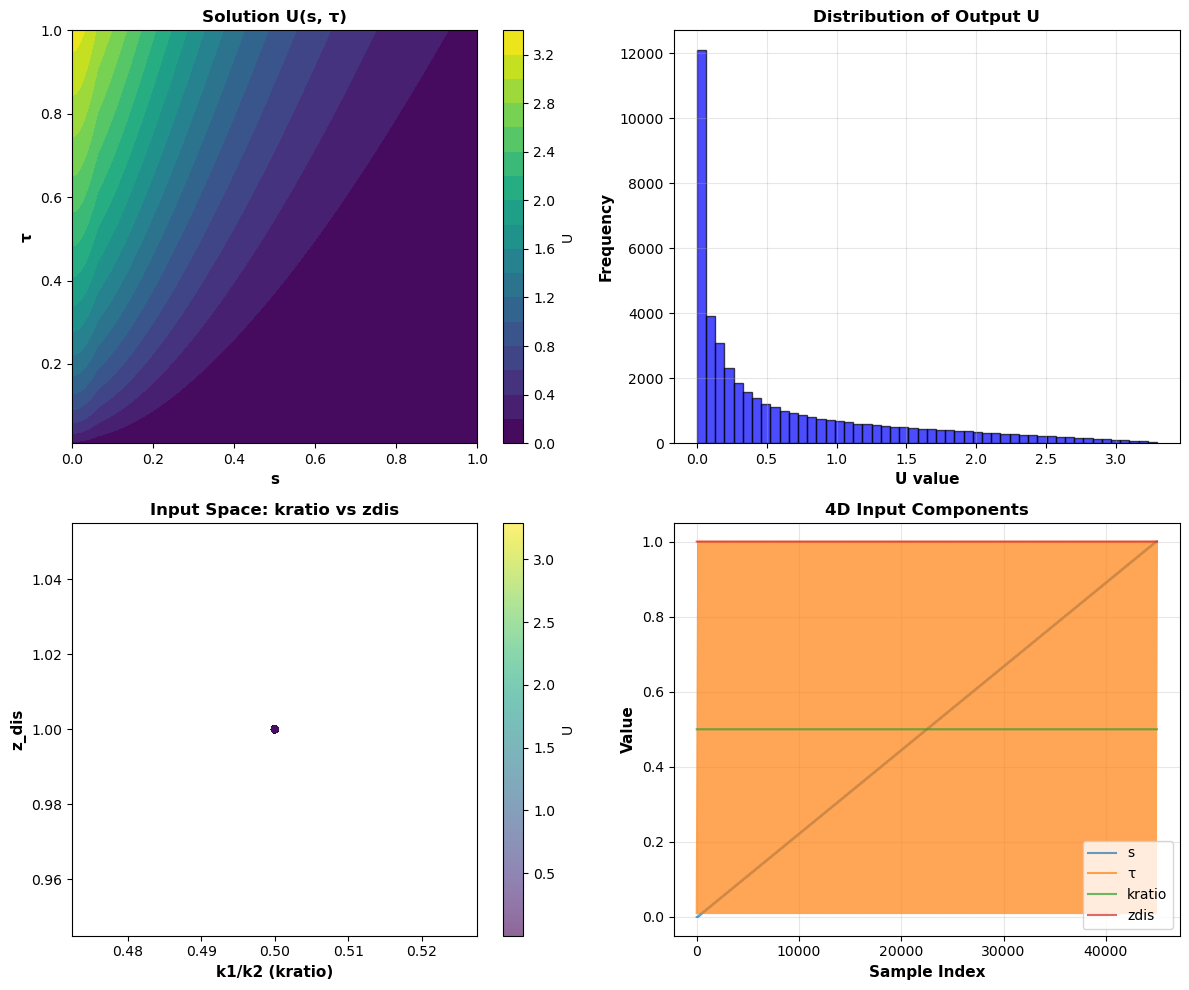

✓ Visualization saved: training_data_4keys_cuda.png


In [40]:
# Move to CPU for visualization
S_cpu = S.cpu().numpy()
TAU_cpu = TAU.cpu().numpy()
U_cpu = U_train.cpu().numpy()
xtrain_cpu = xtrain.cpu().numpy()
ytrain_cpu = ytrain.cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Heatmap: U(s, τ)
ax = axes[0, 0]
contour = ax.contourf(S_cpu, TAU_cpu, U_cpu, levels=20, cmap='viridis')
ax.set_xlabel('s', fontsize=11, fontweight='bold')
ax.set_ylabel('τ', fontsize=11, fontweight='bold')
ax.set_title('Solution U(s, τ)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('U', fontsize=10)

# Distribution of U values
ax = axes[0, 1]
ax.hist(ytrain_cpu.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.set_xlabel('U value', fontsize=11, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Output U', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Input vs Output
ax = axes[1, 0]
scatter = ax.scatter(xtrain_cpu[:, 2], xtrain_cpu[:, 3], c=ytrain_cpu.flatten(), 
                     cmap='viridis', s=20, alpha=0.6)
ax.set_xlabel('k1/k2 (kratio)', fontsize=11, fontweight='bold')
ax.set_ylabel('z_dis', fontsize=11, fontweight='bold')
ax.set_title('Input Space: kratio vs zdis', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('U', fontsize=10)

# 4D input components
ax = axes[1, 1]
ax.plot(xtrain_cpu[:, 0], label='s', linewidth=1.5, alpha=0.7)
ax.plot(xtrain_cpu[:, 1], label='τ', linewidth=1.5, alpha=0.7)
ax.plot(xtrain_cpu[:, 2], label='kratio', linewidth=1.5, alpha=0.7)
ax.plot(xtrain_cpu[:, 3], label='zdis', linewidth=1.5, alpha=0.7)
ax.set_xlabel('Sample Index', fontsize=11, fontweight='bold')
ax.set_ylabel('Value', fontsize=11, fontweight='bold')
ax.set_title('4D Input Components', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_data_4keys_cuda.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Visualization saved: training_data_4keys_cuda.png')